### Gaussian hist for p-value computation

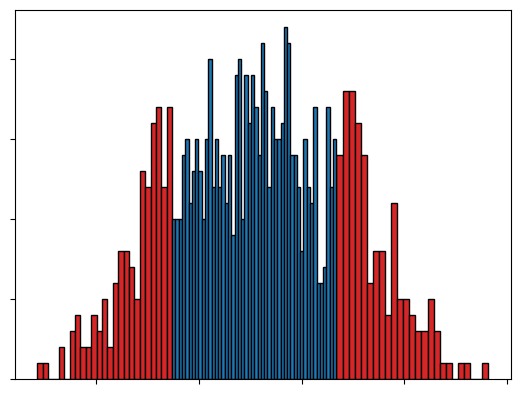

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.random.normal(loc=0.5, scale=0.15, size=(1000))
np.percentile(data, 5)

f, ax = plt.subplots()
# ax.hist(data, bins=100, edgecolor="black", color="#1f77b4")
ax.hist(data[data<=np.percentile(data, 15)], bins=25, edgecolor="black", color="#d62728")
# ax.hist(data[(data>np.percentile(data, 5))], bins=50, edgecolor="black", color="#1f77b4")
ax.hist(data[data>=np.percentile(data, 85)], bins=25, edgecolor="black", color="#d62728")
ax.hist(data[(data>np.percentile(data, 15)) & (data<np.percentile(data, 85))], bins=50, edgecolor="black", color="#1f77b4")
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.show()

### Lines w/ Error Bars for CD Comparison

ACT        PCMCI         DYNO
folder    size                                         
variables small   0.10 ± 0.15  0.23 ± 0.17  0.89 ± 0.29
          medium  0.04 ± 0.07  0.20 ± 0.15  0.94 ± 0.19
          large   0.19 ± 0.14  0.27 ± 0.09  0.91 ± 0.09
samples   small   0.15 ± 0.13  0.18 ± 0.11  0.76 ± 0.17
          medium  0.11 ± 0.10  0.21 ± 0.11  0.92 ± 0.18
          large   0.13 ± 0.28  0.35 ± 0.16  1.06 ± 0.19
density   small   0.20 ± 0.39  0.29 ± 0.07  0.91 ± 0.13
          medium  0.15 ± 0.17  0.20 ± 0.10  0.89 ± 0.21
          large   0.14 ± 0.13  0.21 ± 0.08  0.83 ± 0.26
lags      small   0.02 ± 0.02  0.03 ± 0.05  1.30 ± 0.52
          medium  0.07 ± 0.10  0.27 ± 0.13  0.90 ± 0.21
          large   0.08 ± 0.06  0.19 ± 0.09  0.57 ± 0.15

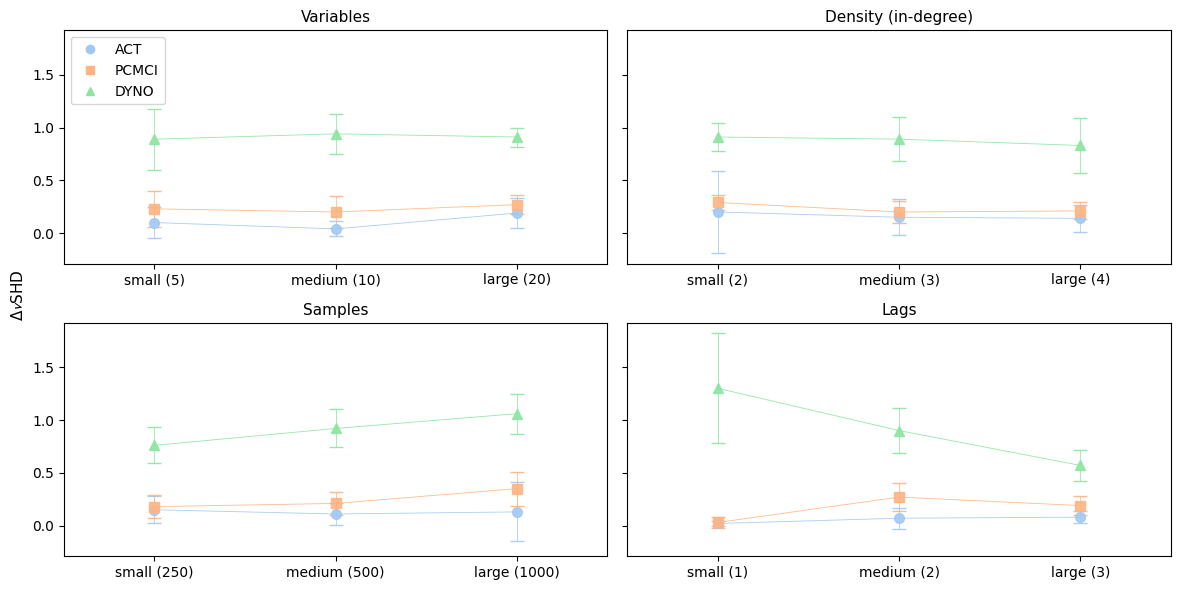

In [26]:
# imports 
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

# folders
folders = ['variables', 'samples', 'density', 'lags']
sizes = ['small', 'medium', 'large']
subfolder = 'iter_b2f_l1'
score = 'dvshd'

res = pd.DataFrame(columns=["ACT", "PCMCI", "DYNO"], 
                   index=pd.MultiIndex.from_product([folders, sizes], names=["folder", "size"]))

for i, data_folder in enumerate(folders[:]):
    for j, folder_size in enumerate(sizes):
        results = pd.read_csv(Path(".").resolve().parents[1] / 'data' / 'results' / 'cd_task' \
                              / subfolder / score / f'cd-task_{data_folder}_{folder_size}.csv').dropna(axis=0, how='any')
        for k, (x, color) in enumerate(zip(results.columns, sns.color_palette("pastel"))):
            res.loc[(data_folder, folder_size), x] = f"{results[x].mean():.2f} ± {results[x].std():.2f}"

# res = res.drop(columns=["LCM"])
display(res)

f, ax = plt.subplots(2, 2, figsize=(12, 6), sharey=True)

markers = ['o', 's', '^', 'D', 'X', '2'][:len(res.columns)]
colors = sns.color_palette("pastel")[:len(res.columns)]
increments = [-0.05, 0, 0.05]
# ------------------------- variables -------------------------
subres = res[res.index.get_level_values('folder')=="variables"]
handles = [mlines.Line2D([], [], color=color, marker=marker, linestyle='None', markersize=6, label=label) 
           for label, color, marker in zip(subres.columns, colors, markers)]
ax[0,0].set_xticks(
    ticks=range(1, len(subres.index.get_level_values('size'))+1, 1), 
    labels=[f"{x[0]} ({x[1]})" for x in zip(subres.index.get_level_values('size'), (5, 10, 20))], 
    rotation=0
)
ax[0,0].set_xlim(0.5, 3.5)
# ax[0,0].set_ylim(0.0, 110)
ax[0,0].set_title("Variables", fontsize=11)
# ax[0,0].set_xlabel("# variables")
# ax[0,0].set_ylabel(score.replace("shd", "SHD").replace("d", "$\Delta$"))
for idy, color, marker in list(zip(subres.columns, colors, markers)):
    for idx in subres.index:
        val = subres.loc[idx, idy]
        if isinstance(val, str):
            mean, std = val.split(" ± ")
            ax[0,0].errorbar(
                x=subres.index.get_level_values('size').get_loc(idx[1]) + 1, y=float(mean), yerr=float(std),
                capsize=5, color=color, alpha=0.9, marker=marker,  markersize='7', elinewidth=0.6
            )
for idy, color in list(zip(subres.columns, colors)):
    ax[0,0].plot(
        [subres.index.get_level_values('size').get_loc(idx[1]) + 1 for idx in subres.index], 
        [float(subres.loc[idx, idy].split(" ± ")[0]) for idx in subres.index],
        '-', alpha=0.9, label=idy, color=color, linewidth=0.6
    )
ax[0,0].legend(handles=handles, loc='upper left', ncol=1)

# ------------------------- samples -------------------------
subres = res[res.index.get_level_values('folder')=="samples"]
handles = [mlines.Line2D([], [], color=color, marker=marker, linestyle='None', markersize=6, label=label) 
           for label, color, marker in zip(subres.columns, colors, markers)]
ax[1,0].set_xticks(
    ticks=range(1, len(subres.index.get_level_values('size')) + 1, 1), 
    labels=[f"{x[0]} ({x[1]})" for x in zip(subres.index.get_level_values('size'), (250, 500, 1000))], 
    rotation=0
)
ax[1,0].set_xlim(0.5, 3.5)
# ax[1,0].set_ylim(0.0, 110)
ax[1,0].set_title("Samples", fontsize=11)
# ax[1,0].set_xlabel("# samples")
# ax[1,0].set_ylabel(score.replace("shd", "SHD").replace("d", "$\Delta$"))
for idy, color, marker in list(zip(subres.columns, colors, markers)):
    for idx in subres.index:
        val = subres.loc[idx, idy]
        if isinstance(val, str):
            mean, std = val.split(" ± ")
            ax[1,0].errorbar(
                x=subres.index.get_level_values('size').get_loc(idx[1]) + 1, y=float(mean), yerr=float(std),
                capsize=5, color=color, alpha=0.9, marker=marker,  markersize='7', elinewidth=0.6
            )
for idy, color in list(zip(subres.columns, colors)):
    ax[1,0].plot(
        [subres.index.get_level_values('size').get_loc(idx[1]) + 1 for idx in subres.index], 
        [float(subres.loc[idx, idy].split(" ± ")[0]) for idx in subres.index],
        '-', alpha=0.9, label=idy, color=color, linewidth=0.6
    )
# ax[1,0].legend(handles=handles, loc='upper left', ncol=2)

# ------------------------- density -------------------------
subres = res[res.index.get_level_values('folder')=="density"]
handles = [mlines.Line2D([], [], color=color, marker=marker, linestyle='None', markersize=6, label=label) 
           for label, color, marker in zip(subres.columns, colors, markers)]
ax[0,1].set_xticks(
    ticks=range(1, len(subres.index.get_level_values('size')) + 1, 1), 
    labels=[f"{x[0]} ({x[1]})" for x in zip(subres.index.get_level_values('size'), (2, 3, 4))], 
    rotation=0
)
ax[0,1].set_xlim(0.5, 3.5)
# ax[0,1].set_ylim(0.0, 110)
ax[0,1].set_title("Density (in-degree)", fontsize=11)
# ax[0,1].set_xlabel("density (mean in-degree)")
# ax[0,1].set_ylabel(score.replace("shd", "SHD").replace("d", "$\Delta$"))
for idy, color, marker in list(zip(subres.columns, colors, markers)):
    for idx in subres.index:
        val = subres.loc[idx, idy]
        if isinstance(val, str):
            mean, std = val.split(" ± ")
            ax[0,1].errorbar(
                x=subres.index.get_level_values('size').get_loc(idx[1]) + 1, y=float(mean), yerr=float(std),
                capsize=5, color=color, alpha=0.9, marker=marker,  markersize='7', elinewidth=0.6
            )
for idy, color in list(zip(subres.columns, colors)):
    ax[0,1].plot(
        [subres.index.get_level_values('size').get_loc(idx[1]) + 1 for idx in subres.index], 
        [float(subres.loc[idx, idy].split(" ± ")[0]) for idx in subres.index],
        '-', alpha=0.9, label=idy, color=color, linewidth=0.6
    )
# ax[0,1].legend(handles=handles, loc='upper left', ncol=2)

# ------------------------- lags -------------------------
subres = res[res.index.get_level_values('folder')=="lags"]
handles = [mlines.Line2D([], [], color=color, marker=marker, linestyle='None', markersize=6, label=label) 
           for label, color, marker in zip(subres.columns, colors, markers)]
ax[1,1].set_xticks(
    ticks=range(1, len(subres.index.get_level_values('size')) + 1, 1), 
    labels=[f"{x[0]} ({x[1]})" for x in zip(subres.index.get_level_values('size'), (1, 2, 3))], 
    rotation=0
)
ax[1,1].set_xlim(0.5, 3.5)
# ax[1,1].set_ylim(0.0, 110)
ax[1,1].set_title("Lags", fontsize=11)
# ax[1,1].set_xlabel("# lags")
# ax[1,1].set_ylabel(score.replace("shd", "SHD").replace("d", "$\Delta$"))
for idy, color, marker in list(zip(subres.columns, colors, markers)):
    for idx in subres.index:
        val = subres.loc[idx, idy]
        if isinstance(val, str):
            mean, std = val.split(" ± ")
            ax[1,1].errorbar(
                x=subres.index.get_level_values('size').get_loc(idx[1]) + 1, y=float(mean), yerr=float(std),
                capsize=5, color=color, alpha=0.9, marker=marker,  markersize='7', elinewidth=0.6
            )
for idy, color in list(zip(subres.columns, colors)):
    ax[1,1].plot(
        [subres.index.get_level_values('size').get_loc(idx[1]) + 1 for idx in subres.index], 
        [float(subres.loc[idx, idy].split(" ± ")[0]) for idx in subres.index],
        '-', alpha=0.9, label=idy, color=color, linewidth=0.6 
    )
# ax[1,1].legend(handles=handles, loc='upper left', ncol=2)

# handles, labels = ax[1,1].get_legend_handles_labels()
# f.legend(handles, labels, loc='upper center', ncol=2)

f.supylabel(score.replace("shd", "SHD").replace("d", "$\Delta$").replace("v", "$\mathcal{v}$"), fontsize=11)

plt.tight_layout()
plt.show()


### Benchmarking the Baselines

benchmark_results_linear_10v_1l_gaussian_fixed_dyno.csv
benchmark_results_linear_10v_2l_gaussian_fixed_dyno.csv
benchmark_results_linear_10v_3l_gaussian_fixed_dyno.csv
benchmark_results_nonlinear_10v_1l_gaussian_fixed_dyno.csv
benchmark_results_nonlinear_10v_2l_gaussian_fixed_dyno.csv
benchmark_results_nonlinear_10v_3l_gaussian_fixed_dyno.csv


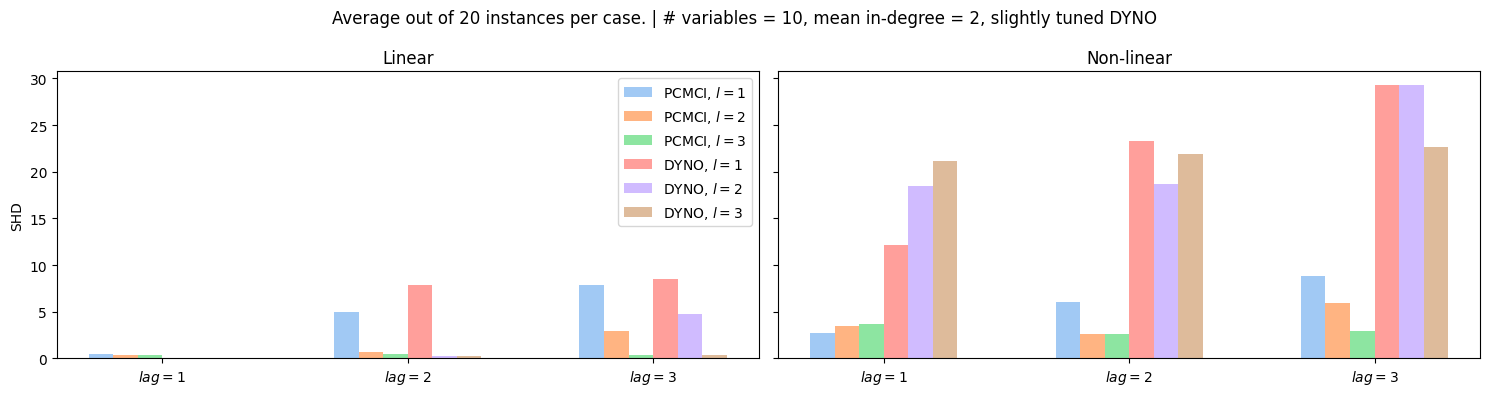

In [19]:
import os
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt

# load data
save_path = list(Path(".").resolve().parents)[1] / 'data' / 'debugging'

f, axs = plt.subplots(ncols=2, figsize=(15, 4), sharey=True)
offsets = [-0.25, -0.15, -0.05, 0.05, 0.15, 0.25]

for ax in axs:
    ax.set_xticks(ticks=[1, 2, 3, 4], labels=["$lag=1$", "$lag=2$", "$lag=3$", ""])

axs[0].set_ylabel("SHD")
axs[0].set_title("Linear")
for x, rfn in enumerate([ x for x in os.listdir(save_path / 'results') if (('nonlinear' not in x) and ('dyno' in x))]):
    print(rfn)
    results = pd.read_csv(save_path / 'results' / rfn)
    colors = sns.color_palette("pastel")[:len(results.columns)]
    for off, color, (method, score) in zip(offsets, colors, results.mean().items()):
        axs[0].bar(x=x+off+1, height=score, width=0.1, color=color, label=method)

axs[1].set_title("Non-linear")
for x, rfn in enumerate([ x for x in os.listdir(save_path / 'results') if (('nonlinear' in x) and ('dyno' in x))]):
    print(rfn)
    results = pd.read_csv(save_path / 'results' / rfn)
    colors = sns.color_palette("pastel")[:len(results.columns)]
    for off, color, (method, score) in zip(offsets, colors, results.mean().items()):
        axs[1].bar(x=x+off+1, height=score, width=0.1, color=color, label=method)


handles, labels = axs[0].get_legend_handles_labels()
labels = [x.replace("_1", ", $l=1$").replace("_2", ", $l=2$").replace("_3", ", $l=3$") for x in labels]
by_label = dict(zip(labels, handles))
axs[0].legend(by_label.values(), by_label.keys())

f.suptitle("Average out of 20 instances per case. | # variables = 10, mean in-degree = 2, slightly tuned DYNO")
f.tight_layout()
plt.show()



### Warm-up Steps

In [29]:
import os
import torch
import numpy as np
import pandas as pd
from copy import deepcopy
from pathlib import Path

from utils import check_non_stationarity
from tempogen.temporal_scm import TempSCM
from simulation.simulation_utils import safe_cd_task
from tempogen.functional_utils import _torch_identity, _torch_sqrt, _torch_sigmoid, _torch_tanh

import sys
sys.path.append("..")


def check_identifiability(true_data):
    try:
        pred_graph = safe_cd_task(true_data=true_data)
        return True
    except Exception as e:
        print(f"ERROR: check_identifiability failed with error: {e}")
        return False

def get_func_kwargs():
    """ """
    return {
        "a": [_torch_identity, _torch_sqrt, _torch_sigmoid, _torch_tanh], 
        "p": [0.25, 0.25, 0.25, 0.25]
    }

def get_z_kwargs():
    """ """
    return {
        "a": [torch.distributions.normal.Normal(loc=0, scale=0.05), torch.distributions.uniform.Uniform(low=-0.1, high=0.1)], 
        "p": [0.5, 0.5]
    }

flag = True
while flag:
    try:
        rng = np.random.default_rng(10)

        # create SCM & sample data
        n_vars = 10
        n_lags = 3
        p_edge = 0.2
        i_degree = 2
        funcs = [rng.choice(**get_func_kwargs()) for _ in range(n_vars)]
        z_distributions = [rng.choice(**get_z_kwargs()) for _ in range(n_vars)]
        scm = TempSCM(
            n_vars=n_vars,                       
            n_lags=n_lags,                       
            p_edge=p_edge,  
            i_degree=i_degree,                   
            funcs=funcs,    
            z_distributions=z_distributions, 
            method="ID"          
        )
        scm_noise = deepcopy(scm)
        data = scm.generate_time_series(500)
        graph = scm.causal_structure.causal_structure_cp
        assert not check_non_stationarity(data), "ValueError: Generated data contain non-stationary time-series."
        assert check_identifiability(data), "ValueError: Generated data may not be identifiable."
        flag = False

    except Exception as e:
        print(f"Exception: {e}")

100%|██████████| 520/520 [00:01<00:00, 275.20it/s]


LOG : Causal structure : estimate_with_PCMCI w/ {'n_lags': 1} ...
LOG : Causal structure : estimate_with_PCMCI was successfully used.


In [41]:
scm_deci = deepcopy(scm_noise)
scm_deci.time_series.loc[:, :] = rng.normal(loc=10, scale=1, size=scm_deci.time_series.shape)

data_noise = scm_noise.generate_time_series(100)
data_deci = scm_deci.generate_time_series(100)

for i in range(0, 100, 10):
    print(" - noise - ")
    print(data_noise.mean())
    print(" - deci - ")
    print(data_deci.mean())
    print(" -------------------------------------------------- ")

100%|██████████| 120/120 [00:00<00:00, 217.61it/s]

 - noise - 
A    0.994469
B    2.954364
C    0.992065
D    1.943891
E    1.000574
F    0.965151
G    0.983631
H    0.964436
I    1.984252
J    0.958982
dtype: float32
 - deci - 
A    8.392745
B    8.850982
C    8.516033
D    8.595406
E    8.422855
F    8.449160
G    8.350924
H    8.454895
I    8.596827
J    8.425185
dtype: float64
 -------------------------------------------------- 
 - noise - 
A    0.994469
B    2.954364
C    0.992065
D    1.943891
E    1.000574
F    0.965151
G    0.983631
H    0.964436
I    1.984252
J    0.958982
dtype: float32
 - deci - 
A    8.392745
B    8.850982
C    8.516033
D    8.595406
E    8.422855
F    8.449160
G    8.350924
H    8.454895
I    8.596827
J    8.425185
dtype: float64
 -------------------------------------------------- 
 - noise - 
A    0.994469
B    2.954364
C    0.992065
D    1.943891
E    1.000574
F    0.965151
G    0.983631
H    0.964436
I    1.984252
J    0.958982
dtype: float32
 - deci - 
A    8.392745
B    8.850982
C    8.516033
D    8.5

### Debugging an ACT archive

In [ ]:
import torch
from cdt.metrics import SHD

def fix_lag_dim(a_graph, b_graph):
    if  a_graph.shape[2]>b_graph.shape[2]:
        b_graph = torch.nn.functional.pad(input=b_graph, pad=(a_graph.shape[2] - b_graph.shape[2], 0, 0, 0, 0, 0), value=0)
    if  b_graph.shape[2]>a_graph.shape[2]:
        a_graph = torch.nn.functional.pad(input=a_graph, pad=(b_graph.shape[2] - a_graph.shape[2], 0, 0, 0, 0, 0), value=0)
    return a_graph, b_graph

def config_barplot(archive, label_graph):

    idx = archive['idx']
    # ...
    shd_per_config = []
    for i in range(len(archive['fit_scm_list'])):
        t_graph = label_graph.clone()
        p_graph = archive['fit_scm_list'][i].causal_structure.causal_structure_cp.clone()
        t_graph, p_graph = fix_lag_dim(t_graph, p_graph)
        shd_per_config.append(SHD(target=t_graph.numpy(), pred=p_graph.numpy()))
    print(list(enumerate(zip(shd_per_config, [round(x, 2) for x in archive['auc_list']]))))
    opt_shd =  min(shd_per_config)
    opt_shd_i = np.argmin(shd_per_config)
    print(f"LOG: ACT: {idx} | Optimal: {opt_shd_i}")

    f, ax = plt.subplots(ncols=1, nrows=1, figsize=(18, 6))
    colors = sns.color_palette(palette="dark:salmon_r", n_colors=len(archive['cfg_list']))

    ax.grid(color='gray', linestyle='dashed')
    ax.set_xticks(ticks=[x for x in range(len(archive['cfg_list']) + 1)], labels=[f"C{x}" for x in range(len(archive['cfg_list']))] + [""])
    ax.set_ylim((0, max(shd_per_config)+5))
    ax.set_xlabel("ACT Configurations")
    ax.set_ylabel("SHD")
    ax.set_title("Example of ACT not selecting the configuration with optimal SHD in its search space.")
    for x, color in zip(range(len(archive['cfg_list'])), colors):
        if x==archive["idx"]:
            text_bbox = dict(boxstyle='square', facecolor='palegreen', alpha=0.5)
        elif x==opt_shd_i:
            text_bbox = dict(boxstyle='square', facecolor='wheat', alpha=0.5)
        else:
            text_bbox = None
        ax.bar(x=x, width=0.2, height=shd_per_config[x], color=color)
        method = archive['cfg_list'][x]['cd']['cd_method']
        lags = archive['cfg_list'][x]['cd']['cd_kwargs']['n_lags']
        auc = round(archive['auc_list'][x], 2)
        s = f"{method} \nL$={lags}$ \nAUC$={auc}$"
        ax.text(x=x-0.5, y=shd_per_config[x]+1, s=s, fontdict={'size': 6, 'fontweight':'bold'}, bbox=text_bbox)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='palegreen', edgecolor='gray', label='Selected by ACT'),
        Patch(facecolor='wheat', edgecolor='gray', label='Best SHD in search space')
    ]
    ax.legend(handles=legend_elements, loc='upper left')
    plt.show()